<a href="https://colab.research.google.com/github/LavanyaDataAnalyst/Metro-Traffic-Pattern-Analysis/blob/main/Metro_Traffic_Pattern_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **US Minneapolis Metro Traffic Pattern Analysis**


# **Objective**

* To Identify patterns, trends, and insights using Exploratory Data Analysis (EDA).
* To Clean and preprocess the dataset for analysis.
* To Create visualizations to explain traffic behavior.
* To Provide actionable insights for traffic management.

# **Outcome**

The project identifies peak traffic periods, weather impacts, and traffic trends to support data-driven traffic management and planning.

# **Domain**
Transportation / Traffic Analytics / Smart City Management



#**Dataset Information**

**Source:** UCI Machine Learning Repository <font color="blue"><u> **https://raw.githubusercontent.com/ManojKumarMaruthi/Regression/refs/heads/master/Metro_Interstate_Traffic_Volume.csv**</font></u>

**Year / Timeline:**
* Traffic data collected from 2012 to 2018
* Dataset published/updated in 2019 on UCI Repository

**Dataset Column/features Description:**


| Column Name         | Description                             |
| ------------------- | --------------------------------------- |
| holiday             | Public holiday indicator                |
| temp                | Temperature (Kelvin)                    |
| rain_1h             | Amount of rainfall recorded in one hour |
| snow_1h             | Amount of snowfall recorded in one hour |
| clouds_all          | Cloud cover percentage                  |
| weather_main        | Main weather condition                  |
| weather_description | Detailed weather condition              |
| date_time           | Date and time of observation            |
| traffic_volume      | Number of vehicles recorded             |


# **Inital EDA**

In [3]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
# Loading dataset
df=pd.read_csv("https://raw.githubusercontent.com/ManojKumarMaruthi/Regression/refs/heads/master/Metro_Interstate_Traffic_Volume.csv")
df

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918
...,...,...,...,...,...,...,...,...,...
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450


In [5]:
# rows and columns
df.shape

(48204, 9)

* The dataset contains 48,204 rows and 9 columns

In [6]:
df.size

433836

* The dataset contains 4,33,836 values.

In [7]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


* The first few rows of the dataset for quick inspection and understanding of the data structure.

In [8]:
df.tail()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
48199,NaN,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,3543
48200,NaN,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,2781
48201,NaN,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,2159
48202,NaN,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,1450
48203,NaN,282.12,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 23:00:00,954


* The last few rows of the dataset for quick inspection and understanding of the data structure.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


* The dataset contains 48,204 records and 9 columns.
* Most columns have complete data without missing values.
* The holiday column contains many missing values, with only 61 non-null entries.
* Numerical columns such as temp, rain_1h, snow_1h, clouds_all, and traffic_volume are stored in integer and float data types.
Categorical columns include holiday, weather_main, and weather_description.
* The date_time column is currently stored as an object data type and may need conversion to datetime format for time-series analysis.
* The dataset is suitable for traffic trend analysis, weather impact analysis, and visualization tasks.

In [10]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


* The dataset contains 48,204 traffic observations.
* The average traffic volume is approximately 3,260 vehicles.
* Traffic volume ranges from 0 to 7,280 vehicles, indicating both low and peak congestion periods.
* The average temperature is 281.21 Kelvin, with values ranging from 0 to 310.07 Kelvin.
* Rainfall and snowfall values are mostly zero, showing that precipitation occurs only during limited time periods.
* The maximum rainfall recorded is 9831.3, indicating the presence of extreme outlier values.
* Cloud cover percentage varies from 0% to 100%, with an average of around 49%.
* The high standard deviation in traffic volume and rainfall indicates significant variation in traffic flow and weather conditions.

In [11]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')

In [12]:
df.dtypes

,0
holiday,object
temp,float64
rain_1h,float64
snow_1h,float64
clouds_all,int64
weather_main,object
weather_description,object
date_time,object
traffic_volume,int64


* The dataset contains both numerical and categorical data types.
temp, rain_1h, and snow_1h are stored as float values because they contain decimal measurements.
* clouds_all and traffic_volume are integer columns representing count-based values.
* holiday, weather_main, and weather_description are categorical/object columns containing text information.
* The date_time column is currently stored as an object data type and should be converted into datetime format for time-based analysis.
* The dataset structure is suitable for exploratory data analysis and visualization.

In [13]:
df.isnull().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


* The holiday column has 48,143 null values, indicating that most days are non-holidays.

In [14]:
df.duplicated().sum()

np.int64(17)

* The dataset contains 17 duplicate records.

**Initial Insights:**


* The dataset contains traffic and weather-related information collected over multiple years.
* Traffic volume appears to be influenced by weather conditions, holidays, and time-related factors.
* The presence of date and time information enables time-series and trend analysis.
* Weather-related variables such as temperature, rainfall, snowfall, and cloud cover can help analyze environmental impact on traffic.
* The dataset is suitable for identifying peak traffic periods and congestion patterns.
* Numerical features show a wide range of values, indicating variation in traffic and weather conditions.
* The dataset can support visualization, forecasting, and traffic management analysis.

# **Data Cleaning and Pre-processing**


In [15]:
# Handling missing values (impute or drop)
df['holiday'].isnull().sum()

np.int64(48143)

In [16]:
df['holiday']=df['holiday'].fillna('No holiday')

In [17]:
df['holiday'].isnull().sum()

np.int64(0)

In [18]:
# Handling duplicate values
df.duplicated().sum()

np.int64(17)

In [19]:
df[df.duplicated()]

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
18697,No holiday,286.290,0.0,0.0,1,Clear,sky is clear,2015-09-30 19:00:00,3679
23851,No holiday,289.060,0.0,0.0,90,Clouds,overcast clouds,2016-06-01 10:00:00,4831
26784,No holiday,289.775,0.0,0.0,56,Clouds,broken clouds,2016-09-21 15:00:00,5365
26980,No holiday,287.860,0.0,0.0,0,Clear,Sky is Clear,2016-09-29 19:00:00,3435
27171,No holiday,279.287,0.0,0.0,56,Clouds,broken clouds,2016-10-07 18:00:00,4642
28879,No holiday,267.890,0.0,0.0,90,Snow,light snow,2016-12-06 18:00:00,4520
29268,No holiday,254.220,0.0,0.0,1,Clear,sky is clear,2016-12-19 00:00:00,420
34711,No holiday,295.010,0.0,0.0,40,Clouds,scattered clouds,2017-06-21 11:00:00,4808
34967,No holiday,292.840,0.0,0.0,1,Clear,sky is clear,2017-06-30 10:00:00,4638
34969,No holiday,294.520,0.0,0.0,1,Clear,sky is clear,2017-06-30 11:00:00,4725


* No duplicate removal was performed, as these records reflect actual events and are not data entry errors.

In [98]:
# Renaming the columns
df.rename(columns={'holiday':'Holiday_Name',
    'temp':'Temperature',
    'rain_1h':'Rainfall_Per_Hr',
    'snow_1h':'Snowfall_Per_Hr',
    'clouds_all':'Cloud_Cover_Percentage',
    'weather_main':'Weather_Condition',
    'weather_description':'Weather_Details',
    'date_time':'Date_Time',
    'traffic_volume':'Traffic_Volume'},inplace=True)

In [21]:
# Extracting Numberic columns
Num_col=df.select_dtypes(include='number')

In [22]:
Num_col.columns

Index(['Temperature', 'Rainfall_Per_Hr', 'Snowfall_Per_Hr',
       'Cloud_Cover_Percentage', 'Traffic_Volume'],
      dtype='object')

In [23]:
# checking skewness
Num_col.skew()

,0
Temperature,-2.247226
Rainfall_Per_Hr,219.389036
Snowfall_Per_Hr,48.367484
Cloud_Cover_Percentage,-0.197257
Traffic_Volume,-0.089381


In [24]:
# checking Kurtosis
Num_col.kurt()

,0
Temperature,39.915068
Rainfall_Per_Hr,48155.626807
Snowfall_Per_Hr,2620.465829
Cloud_Cover_Percentage,-1.742266
Traffic_Volume,-1.309088


* Extreme skewness and kurtosis in precipitation-related features are natural in real-world weather data and were retained for analysis.

In [25]:
# Checking data types
df.dtypes

,0
Holiday_Name,object
Temperature,float64
Rainfall_Per_Hr,float64
Snowfall_Per_Hr,float64
Cloud_Cover_Percentage,int64
Weather_Condition,object
Weather_Details,object
Date_Time,object
Traffic_Volume,int64


In [26]:
# Changing data type in Date_Time column from object to date_time
df['Date_Time']=pd.to_datetime(df['Date_Time'])


In [27]:
df['Date_Time'].dtype

dtype('<M8[ns]')

* The Date_Time field was transformed into a datetime datatype.

In [135]:
# Categorising the Traffic_Volume
df['Traffic_Density']=pd.cut(df['Traffic_Volume'],bins=[0,1000,3000,5000,6000,7500],labels=['Very Low','Low','Moderate','High','Very High'],include_lowest=True)
df['Traffic_Density']

,Traffic_Density
0,High
1,Moderate
2,Moderate
3,High
4,Moderate
...,...
48199,Moderate
48200,Low
48201,Low
48202,Low


## **EDA and Visualizations**

In [29]:
df.columns


Index(['Holiday_Name', 'Temperature', 'Rainfall_Per_Hr', 'Snowfall_Per_Hr',
       'Cloud_Cover_Percentage', 'Weather_Condition', 'Weather_Details',
       'Date_Time', 'Traffic_Volume', 'Traffic_Density'],
      dtype='object')

In [30]:
Num_col

,Temperature,Rainfall_Per_Hr,Snowfall_Per_Hr,Cloud_Cover_Percentage,Traffic_Volume
0,288.28,0.0,0.0,40,5545
1,289.36,0.0,0.0,75,4516
2,289.58,0.0,0.0,90,4767
3,290.13,0.0,0.0,90,5026
4,291.14,0.0,0.0,75,4918
...,...,...,...,...,...
48199,283.45,0.0,0.0,75,3543
48200,282.76,0.0,0.0,90,2781
48201,282.73,0.0,0.0,90,2159
48202,282.09,0.0,0.0,90,1450


In [31]:
df['Traffic_Volume']

,Traffic_Volume
0,5545
1,4516
2,4767
3,5026
4,4918
...,...
48199,3543
48200,2781
48201,2159
48202,1450


In [97]:
df[df['Traffic_Volume']>7050]

,Holiday_Name,Temperature,Rainfall_Per_Hr,Snowfall_Per_Hr,Cloud_Cover_Percentage,Weather_Condition,Weather_Details,Date_Time,Traffic_Volume,Traffic_Density,Temp_in_Cel
332,No holiday,274.81,0.0,0.0,20,Clouds,few clouds,2012-10-16 07:00:00,7055,Very High,1.66
974,No holiday,277.41,0.0,0.0,90,Drizzle,light intensity drizzle,2012-11-07 07:00:00,7088,Very High,4.26
975,No holiday,277.41,0.0,0.0,90,Mist,mist,2012-11-07 07:00:00,7088,Very High,4.26
1189,No holiday,278.02,0.0,0.0,75,Clouds,broken clouds,2012-11-14 16:00:00,7189,Very High,4.87
1697,No holiday,282.45,0.0,0.0,90,Mist,mist,2012-12-04 07:00:00,7051,Very High,9.30
3940,No holiday,264.42,0.0,0.0,40,Mist,mist,2013-02-27 07:00:00,7067,Very High,-8.73
3941,No holiday,264.42,0.0,0.0,40,Fog,fog,2013-02-27 07:00:00,7067,Very High,-8.73
4926,No holiday,277.53,0.0,0.0,90,Mist,mist,2013-04-09 07:00:00,7110,Very High,4.38
4927,No holiday,277.53,0.0,0.0,90,Drizzle,drizzle,2013-04-09 07:00:00,7110,Very High,4.38
5141,No holiday,271.81,0.0,0.0,90,Snow,heavy snow,2013-04-15 07:00:00,7082,Very High,-1.34


In [33]:
df['Holiday_Name'].value_counts()

,count
Holiday_Name,
No holiday,48143
Labor Day,7
Christmas Day,6
Thanksgiving Day,6
Martin Luther King Jr Day,6
New Years Day,6
Veterans Day,5
Columbus Day,5
Memorial Day,5


In [34]:
df['Traffic_Density'].value_counts()

,count
Traffic_Density,
Moderate,15338
Very Low,10993
Low,10529
High,7840
Very High,3502


In [35]:
df.describe()

,Temperature,Rainfall_Per_Hr,Snowfall_Per_Hr,Cloud_Cover_Percentage,Date_Time,Traffic_Volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,2016-01-05 10:46:16.773711616,3259.818355
min,0.000000,0.000000,0.000000,0.000000,2012-10-02 09:00:00,0.000000
25%,272.160000,0.000000,0.000000,1.000000,2014-02-06 11:45:00,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,2016-06-11 03:30:00,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,2017-08-11 06:00:00,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,2018-09-30 23:00:00,7280.000000
std,13.338232,44.789133,0.008168,39.015750,NaN,1986.860670


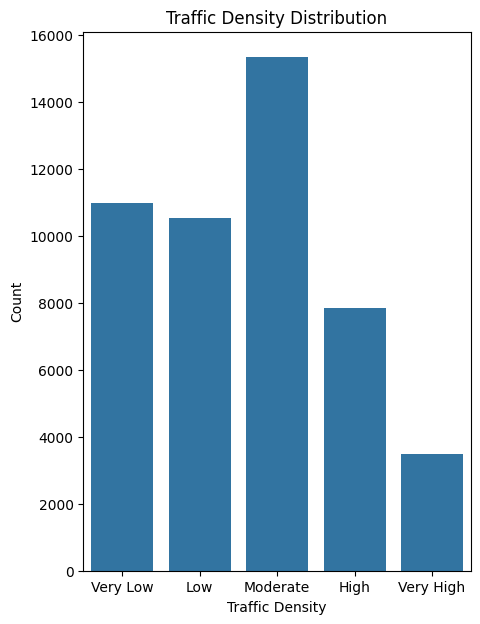

In [136]:
plt.figure(figsize=(5,7))
sns.countplot(x='Traffic_Density', data=df)
plt.xlabel('Traffic Density')
plt.ylabel('Count')
plt.title('Traffic Density Distribution')
plt.show()

**Interpretation:**
* The traffic density countplot reveals the frequency distribution of different traffic density levels, highlighting the most and least common traffic conditions in the dataset.

**Features used:**
Traffic Density

**Insights:**
* Moderate traffic density is the most common category, with approximately 15,300 records.
* Very Low and Low traffic densities are also frequent, with around 11,000 and 10,500records respectively.
* High traffic density occurs less often, accounting for about 7,800 records.
* Very High traffic density is the least frequent category, with only about 3,500 records.

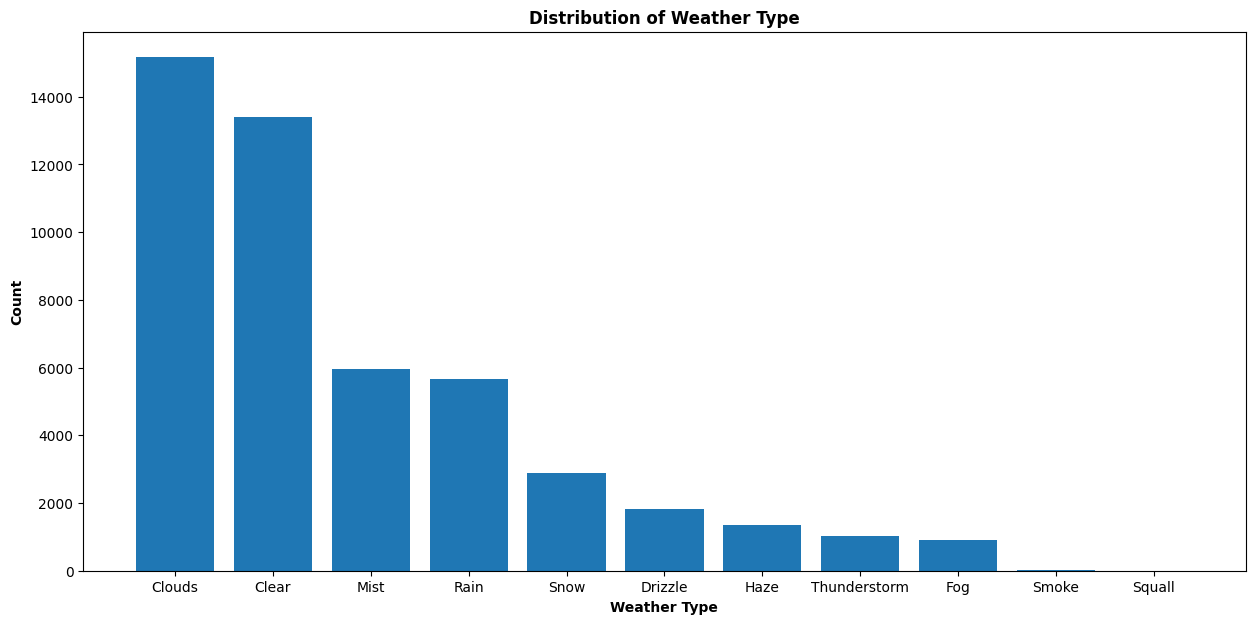

In [42]:
plt.figure(figsize=(15,7))
plt.bar(df['Weather_Condition'].value_counts().index,df['Weather_Condition'].value_counts().values)
plt.xlabel('Weather Type',fontweight='bold')
plt.ylabel('Count',fontweight='bold')
plt.title('Distribution of Weather Type',fontweight='bold')
plt.show()

**Interpretation:**
* The weather type countplot reveals the frequency distribution of different weather conditions, highlighting the most and least prevalent weather patterns in the dataset.

**Features used:**
Weather Condition

**Insights:**
* Cloudy weather is the most common weather condition in the dataset.
* Clear weather is also very common, showing that most days had normal weather conditions.
* Mist and Rain occur sometimes, but much less often than Cloudy and Clear weather.
* Snow, Fog, Thunderstorms, Smoke, and Squall are rare, meaning extreme weather conditions happened only a few times.

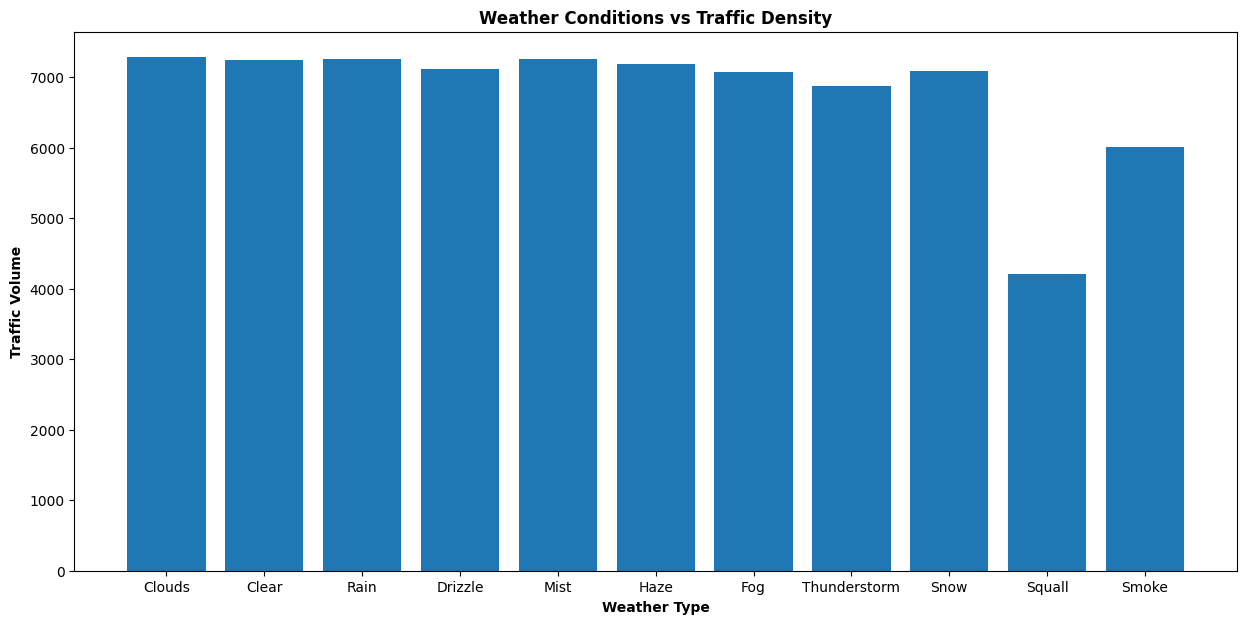

In [137]:
plt.figure(figsize=(15,7))
plt.bar(df['Weather_Condition'],df['Traffic_Volume'])
plt.xlabel('Weather Type',fontweight='bold')
plt.ylabel('Traffic Volume',fontweight='bold')
plt.title('Weather Conditions vs Traffic Density',fontweight='bold')
plt.show()

**Interpretation:**
* The barplot reveals the relationship between weather conditions and average traffic volume, showing how traffic levels vary across different weather types.

**Features used:**
Weather Condition and Traffic Volume

**Insights:**
* Traffic volume remains high across most weather conditions, showing that weather has only a limited impact on overall traffic flow.
* Cloudy, Clear, Rainy, and Misty weather have similar traffic volumes, indicating that people continue to travel even during light rain or reduced visibility.
* Haze records the highest traffic volume, while Thunderstorms show a slightly lower traffic volume compared to other common weather conditions.
* Squall and Smoke have the lowest traffic volumes, suggesting that severe or unusual weather conditions may reduce traffic movement.

In [39]:
fig=px.line(df,x='Date_Time',y='Traffic_Volume',title='Traffic Volume Over Time', width=1000,
    height=500,markers=True)
fig.show()

**Interpretation:**
* The line chart reveals the trend and fluctuations in traffic volume over time, highlighting periods of increasing and decreasing traffic activity.

**Features used:**
Date Time, Traffic Volume

**Insights:**
* Traffic volume remains consistently high throughout the years, with most values ranging between 5,000 and 7,000 vehicles.
* Traffic levels show regular fluctuations over time, indicating variations in daily and hourly traffic patterns.
* There is no significant upward or downward trend in traffic volume, suggesting that overall traffic demand remained stable during the observed period.
* A gap in the timeline around 2014–2015 suggests the presence of missing data or a period when traffic observations were not recorded.

In [138]:
fig = px.pie(
    values=df['Traffic_Density'].value_counts().values,
    names=df['Traffic_Density'].value_counts().index,title='Traffic Density Distribution')
fig.update_traces(textinfo='percent+label')
fig.show()

**Interpretation:**

* The interactive pie chart reveals the proportion of each traffic density category, highlighting the relative share and prevalence of different traffic conditions in the dataset.

**Features used:**
Traffic Density

**Insights:**
* Moderate traffic density is the most common category (31.8%).
* Low and Very Low traffic conditions account for a large share of the data.
* High traffic density occurs less frequently.
* Very High traffic density is the least common, indicating rare severe congestion.

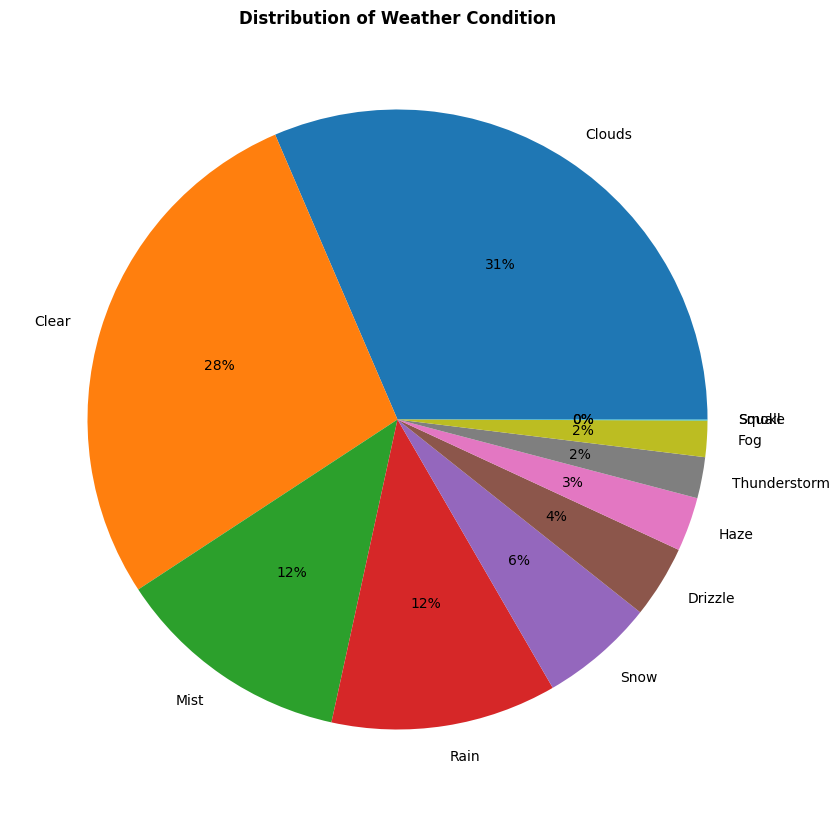

In [69]:
plt.figure(figsize=(10,30))
plt.pie(df['Weather_Condition'].value_counts().values,labels=df['Weather_Condition'].value_counts().index,autopct='%1.0f%%')
plt.title('Distribution of Weather Condition',fontweight='bold')
plt.show()

**Interpretation:**
* The pie chart reveals the proportional distribution of different weather conditions, highlighting the most and least prevalent weather types in the dataset.

**Features used:**
Weather Condition

**Insights:**
* Cloudy weather is the most common condition, accounting for 31% of observations.
* Clear weather is the second most frequent, contributing 28%.
* Mist and Rain each make up 12%, indicating moderate occurrence.
* Snow accounts for 6%, while Drizzle (4%) and Haze (3%) are less common.
* Thunderstorms and Fog are relatively rare, each representing 2% of the data.
* Smoke has a negligible occurrence (0%), making it the least frequent weather condition.
* Nearly 60% of the observations occur under clear or cloudy conditions, suggesting that normal weather dominates the dataset.

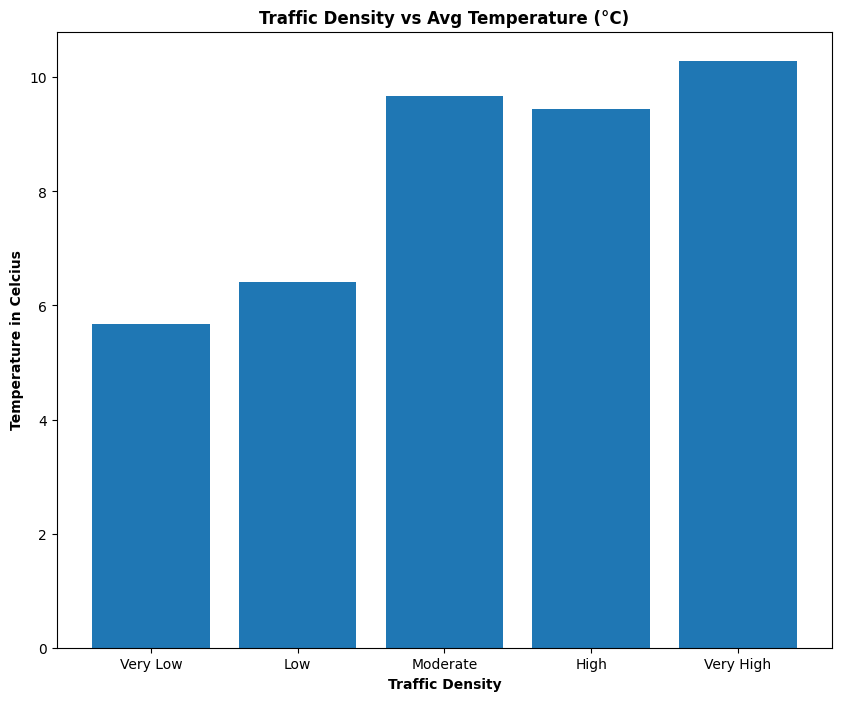

In [139]:
df['Temp_in_Cel']=(df['Temperature']-273.15)
temp_density = df.groupby('Traffic_Density')['Temp_in_Cel'].mean()
plt.figure(figsize=(10,8))
plt.bar(temp_density.index, temp_density.values)
plt.xlabel('Traffic Density',fontweight='bold')
plt.ylabel('Temperature in Celcius',fontweight='bold')
plt.title('Traffic Density vs Avg Temperature (°C)',fontweight='bold')
plt.show()

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)


**Interpretation:**
* The bar chart reveals the relationship between traffic density and average temperature (°C), showing how temperature varies across different traffic density levels.

**Features used:**
Traffic Density, Temp in Cel

**Insights:**
* Average temperature increases as traffic density increases.
* Very High traffic density has the highest average temperature (around 10°C).
* Very Low traffic density has the lowest average temperature (around 6°C).
* Moderate, High, and Very High traffic levels are associated with relatively warmer temperatures.

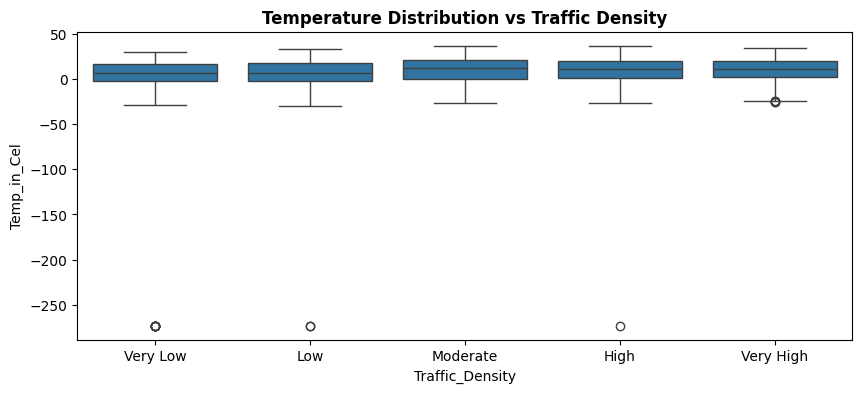

In [140]:
plt.figure(figsize=(10,4))
sns.boxplot(x='Traffic_Density', y='Temp_in_Cel', data=df)
plt.title('Temperature Distribution vs Traffic Density',fontweight='bold')
plt.show()

* A few extreme outliers are present in the data; these should be retained because they may represent real weather observations rather than data entry errors.

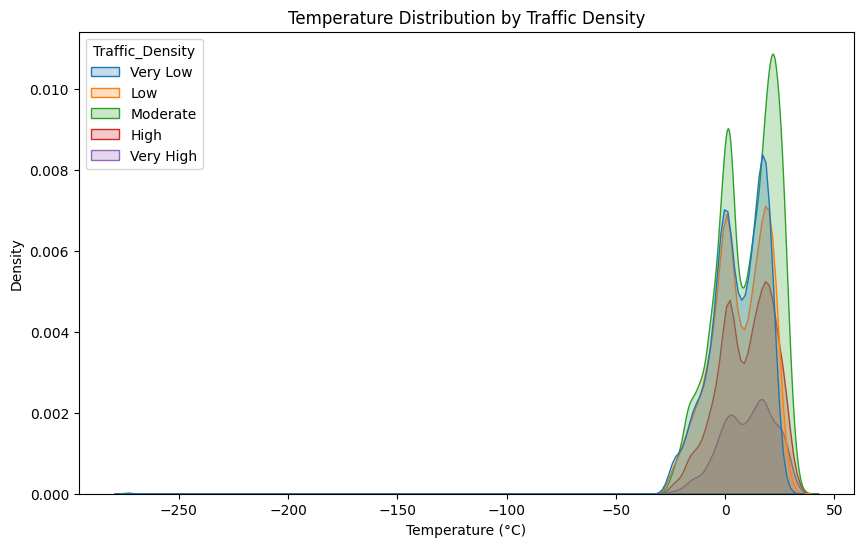

In [141]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df,x='Temp_in_Cel',hue='Traffic_Density',fill=True)
plt.title('Temperature Distribution by Traffic Density')
plt.xlabel('Temperature (°C)')
plt.ylabel('Density')
plt.show()

**Interpretation:**
* The KDE plot reveals the distribution of temperature across different traffic density levels, highlighting variations and overlaps in temperature patterns associated with each traffic category.

**Features used:**
Traffic Density, Temp in Cel

**Insights:**
* Most temperature values are between 0°C and 25°C across all traffic density levels.
* Moderate traffic density shows the highest concentration of observations.
* Temperature distributions are similar for all traffic density categories.
* A few extreme outliers are present and should be investigated before removal.

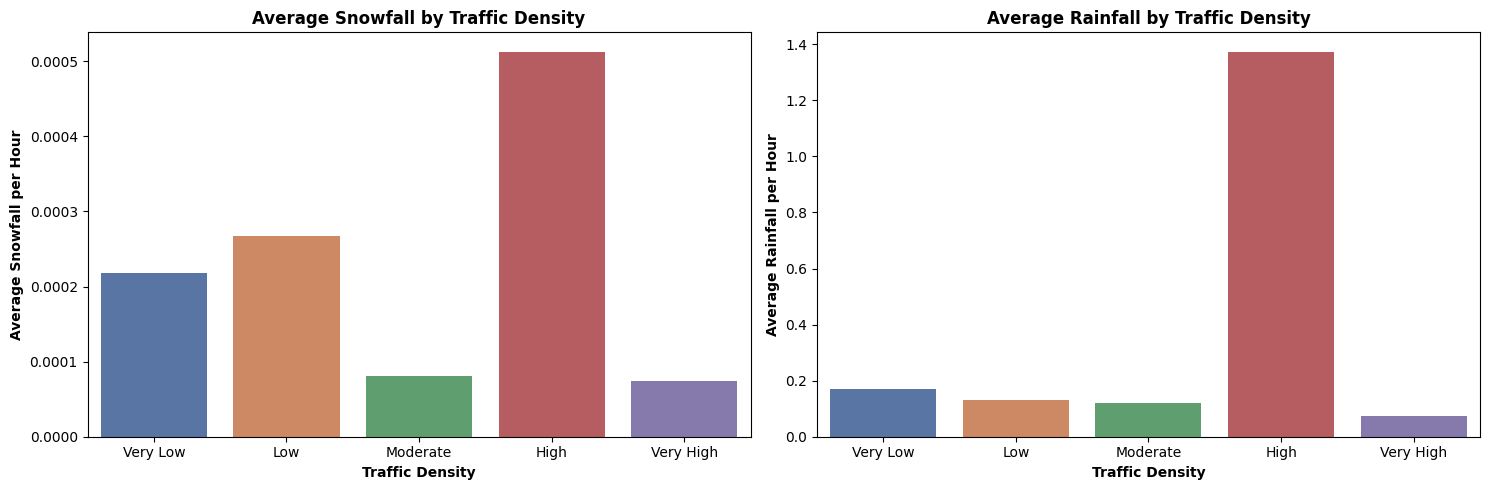

In [142]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

rain_density = df.groupby('Traffic_Density')['Rainfall_Per_Hr'].mean()
snow_density = df.groupby('Traffic_Density')['Snowfall_Per_Hr'].mean()

# Snowfall plot
sns.barplot(
    x=snow_density.index,
    y=snow_density.values,
    palette='deep',
    ax=ax[0])

ax[0].set_xlabel('Traffic Density', fontweight='bold')
ax[0].set_ylabel('Average Snowfall per Hour', fontweight='bold')
ax[0].set_title('Average Snowfall by Traffic Density', fontweight='bold')

# Rainfall plot
sns.barplot(
    x=rain_density.index,
    y=rain_density.values,
    palette='deep',
    ax=ax[1])

ax[1].set_xlabel('Traffic Density', fontweight='bold')
ax[1].set_ylabel('Average Rainfall per Hour', fontweight='bold')
ax[1].set_title('Average Rainfall by Traffic Density', fontweight='bold')

plt.tight_layout()
plt.show()

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

**Interpretation:**
* The subplot bar charts reveal the relationship between traffic density and average snowfall and rainfall, showing how precipitation levels vary across different traffic density categories.

**Features used:**
Traffic Density, Rainfall Per Hr, Snowfall Per Hr

**Insights:**
* High traffic density has the highest average rainfall, significantly higher than all other categories.
* Very Low, Low, and Moderate traffic densities have similar rainfall levels.
* Very High traffic density shows the lowest average rainfall.
* Rainfall appears to have a noticeable impact on traffic, especially during High traffic conditions.
* High traffic density records the highest average snowfall per hour.
* Moderate and Very High traffic densities have the lowest snowfall levels.
* Low and Very Low traffic densities show moderate snowfall.
* No clear linear relationship exists between traffic density and snowfall.
* High traffic is a noticeable outlier with significantly higher snowfall.


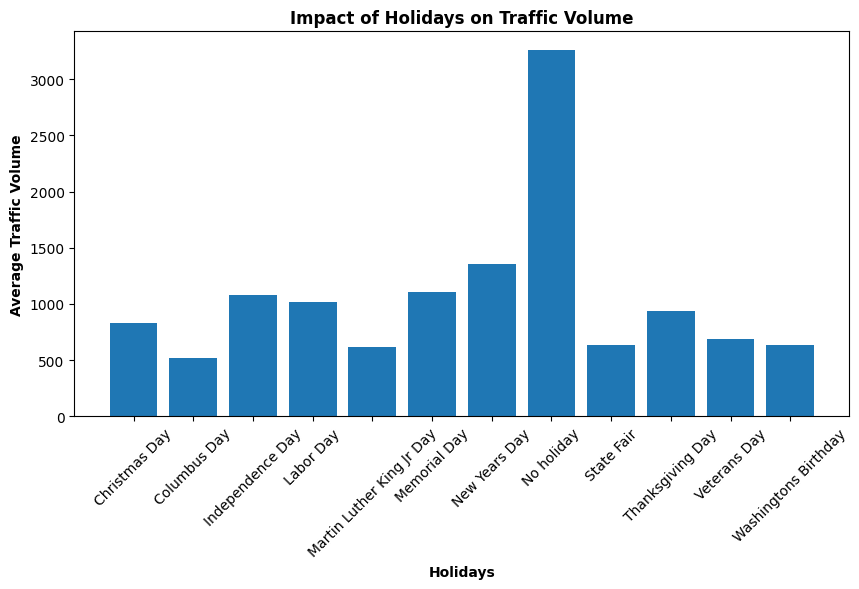

In [106]:
holiday_traffic = df.groupby('Holiday_Name')['Traffic_Volume'].mean()

plt.figure(figsize=(10,5))
plt.bar(holiday_traffic.index, holiday_traffic.values)

plt.xlabel('Holidays', fontweight='bold')
plt.ylabel('Average Traffic Volume', fontweight='bold')
plt.title('Impact of Holidays on Traffic Volume',fontweight='bold')
plt.xticks(rotation=45)
plt.show()

**Interpretation:**
* The bar chart reveals the impact of holidays on average traffic volume, highlighting variations in traffic patterns across different holiday periods compared to regular days.

**Features used:**
Holiday Name, Traffic Volume

**Insights:**
* Traffic volume is highest on non-holidays, significantly exceeding all holiday periods.
* New Year's Day records the highest traffic among holidays.
* Memorial Day, Independence Day, and Labor Day show relatively high traffic volumes.
* Columbus Day has the lowest average traffic volume.
* Most holidays experience reduced traffic compared to non-holiday days, indicating a holiday effect on traffic patterns.

## **Download cleaned data for dashboard creation using Power BI**

In [144]:

# Saving file in computer
df.to_csv("US_Minneapolis_Metro_Traffic_Pattern_Cleaned_Dataset.csv")

from google.colab import files
files.download("US_Minneapolis_Metro_Traffic_Pattern_Cleaned_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Dashboard**

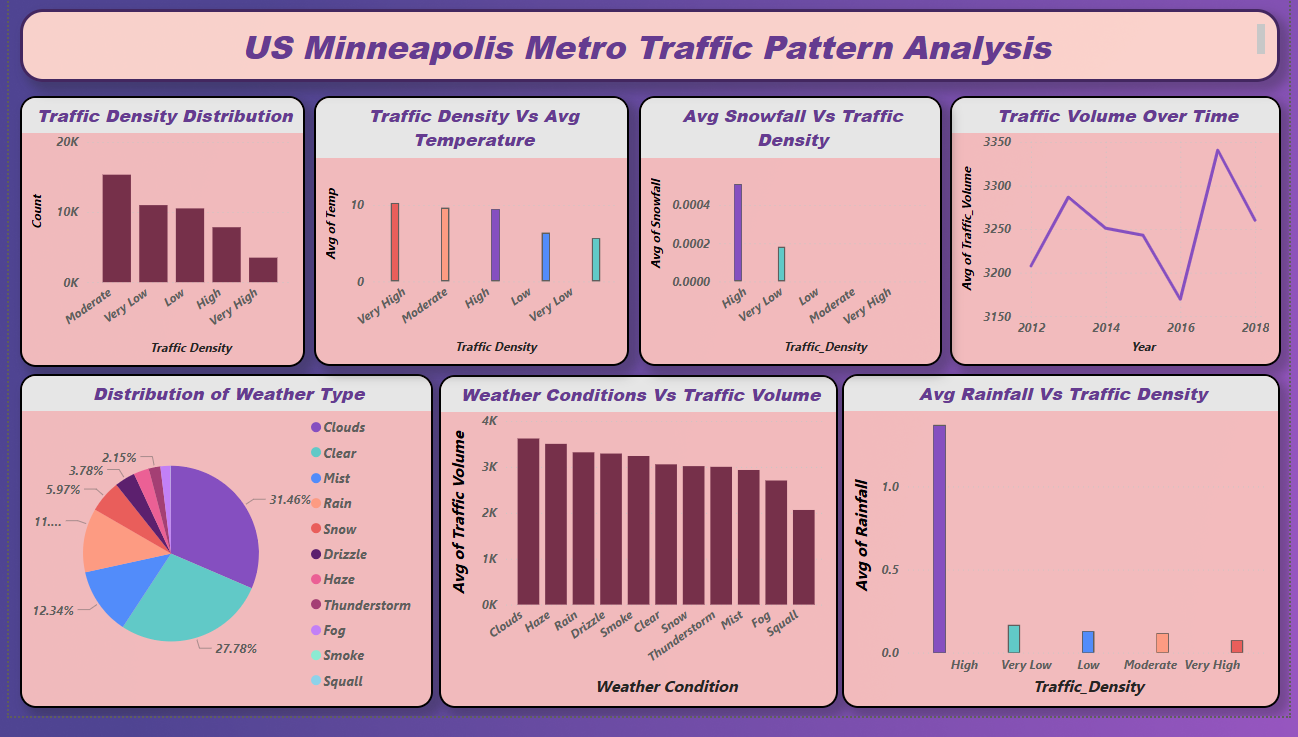

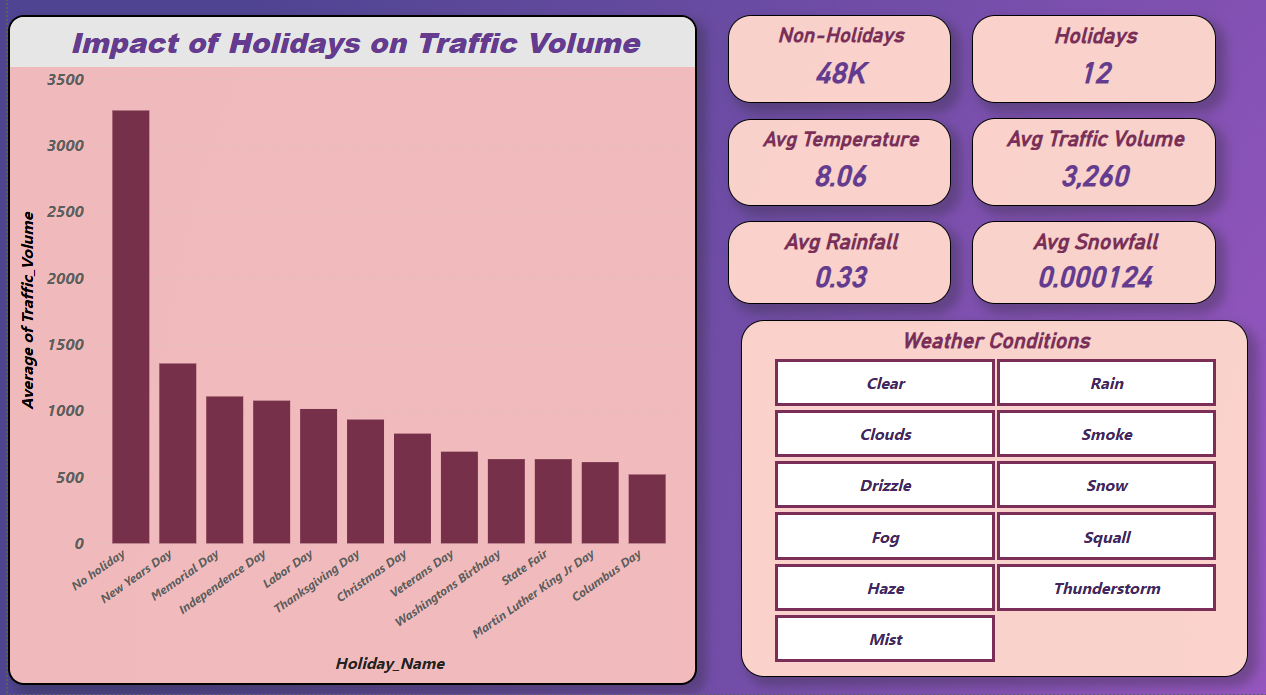

**Documentation link:**

https://drive.google.com/file/d/1dOV7YJUTF-dXopb6I1oZ0oN7pgbO__Jt/view?usp=sharing

# **Final Overall Insights**

* Analyzed historical traffic volume data to understand overall traffic patterns.
* Identified the distribution of traffic across different density levels.
* Summarized weather conditions, rainfall, snowfall, and traffic volumes.
* Investigated the relationship between weather conditions and traffic volume.
* Examined how rainfall, snowfall, and cloud cover influenced traffic density.
* Identified peak congestion periods and factors contributing to higher traffic volumes.
* Historical traffic patterns indicate recurring congestion during peak traffic periods.
* Weather conditions can be used as indicators to anticipate changes in traffic volume.
* Traffic density categories can help estimate future congestion levels.
* Traffic authorities can implement congestion management strategies during peak hours.
* Real-time weather monitoring can support proactive traffic control measures.
* Route optimization and traffic signal adjustments can help reduce congestion.
* Predictive traffic alerts can improve commuter planning and road utilization.

# **Future Enhancement**

* Integrate real-time traffic data for live monitoring and analysis.
* Incorporate GPS and route-level traffic information.
* Develop machine learning models for traffic volume forecasting.
* Build automated congestion prediction and alert systems.
* Include accident, roadwork, and event-based traffic impact analysis.
* Create interactive Power BI dashboards with advanced drill-through capabilities.
* Implement geospatial visualizations for location-specific traffic analysis.
* Integrate weather forecast data for proactive traffic management.

# **Conclusion**

* Successfully cleaned, transformed, and analyzed the Metro Traffic dataset.
* Identified key traffic patterns and congestion trends across different traffic density levels.
* Examined the impact of weather conditions such as rainfall and snowfall on traffic volume.
* Created meaningful visualizations and an interactive Power BI dashboard for better decision-making.
* The analysis provides valuable insights that can support traffic management and transportation planning.
* The project demonstrates how data analytics can be used to understand and improve traffic operations.